# 06. MLOps Lifecycle: MLflow Tracking, Model Registry, Drift Monitoring & Serving

## 1. Objectives & Production Architecture
A reliable production forecasting system requires end-to-end MLOps lifecycle management beyond model development:

1. **Experiment Tracking (`MLflow`)**: Centralized logging of hyperparameter configurations, rolling backtest validation metrics (WRMSSE, WAPE, RMSE), and serializing model artifacts.
2. **Model Registry (`Champion vs Challenger`)**: Automated model governance that promotes candidate models to `champion` only when they outperform the current production benchmark.
3. **Data Drift Monitoring (`Population Stability Index - PSI`)**: Continuously monitors incoming feature distributions and prediction volumes for population shifts, triggering retraining alerts before degradation harms supply chain inventory.
4. **Production Microservice (`FastAPI`)**: Async REST endpoint serving real-time 28-day forecasts with conformal uncertainty bounds.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add root to sys.path
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(root_dir))

from mlops.monitoring.drift import DriftDetector, calculate_psi
from mlops.registry.manager import ModelRegistryManager
from mlops.tracking.tracker import ExperimentTracker
from src.data.loader import generate_synthetic_m5_data, load_raw_data
from src.data.preprocess import melt_sales_data, merge_calendar_and_prices
from src.evaluation.backtest import run_backtest
from src.features.pipeline import build_feature_table
from src.models.gbm import LightGBMForecaster
from src.utils.config import load_config
from src.utils.logger import get_logger

# Visual styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

config = load_config(root_dir / "configs" / "model_config.yaml")
logger = get_logger("mlops_notebook")
print(f"Project: {config.project.get('name')} | Experiment: retail-demand-forecast")

c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project: retail-demand-forecast-engine | Experiment: retail-demand-forecast


## 2. Ingestion & Feature Engineering

In [2]:
SAMPLE_SERIES = 75

try:
    cal_df, prc_df, sal_df = load_raw_data(root_dir / "data" / "raw", nrows=SAMPLE_SERIES)
    print(f"Loaded {len(sal_df)} series from data/raw")
except Exception as e:
    print(f"Raw data not found ({e}). Using synthetic M5 dataset...")
    cal_df, prc_df, sal_df = generate_synthetic_m5_data(
        num_items=75, num_stores=2, num_days=365, random_seed=42
    )

sales_long = melt_sales_data(sal_df)
merged_df = merge_calendar_and_prices(sales_long, cal_df, prc_df)
feat_df = build_feature_table(merged_df)
print(f"Prepared feature dataset: {len(feat_df):,} rows x {len(feat_df.columns)} columns")

2026-08-26 17:20:28 | INFO     | src.data.loader:load_raw_data:81 - Loading calendar from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\calendar.csv...
2026-08-26 17:20:28 | INFO     | src.data.loader:load_raw_data:85 - Loading sales data from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\sales_train_evaluation.csv (nrows=75)...
2026-08-26 17:20:28 | INFO     | src.data.loader:load_raw_data:92 - Loading sell prices from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\sell_prices.csv...
Loaded 75 series from data/raw
2026-08-26 17:20:29 | INFO     | src.data.preprocess:melt_sales_data:33 - Melting sales data from 1941 day columns across 75 series...
2026-08-26 17:20:29 | INFO     | src.data.preprocess:merge_calendar_and_prices:58 - Merging sales data with calendar...
2026-08-26 17:20:29 | INFO     | src.data.preprocess:merge_calendar_and_prices:70 - Merging sell prices on store_id, item_id, and wm_yr_wk...
2026-

## 3. MLflow Experiment Tracking & Backtesting
We log parameters, 3-fold rolling cross-validation metrics, and model artifacts to MLflow.

In [3]:
tracker = ExperimentTracker(
    experiment_name="retail-demand-forecast", tracking_uri="sqlite:///mlflow.db"
)
registry = ModelRegistryManager(
    model_name="retail-demand-champion", tracking_uri="sqlite:///mlflow.db"
)

with tracker.start_run(run_name="LightGBM_Production_Candidate"):
    candidate_model = LightGBMForecaster(
        n_estimators=150,
        learning_rate=0.06,
        num_leaves=31,
        tweedie_variance_power=1.15,
    )

    agg_metrics, oof_df, fold_summaries = run_backtest(
        model=candidate_model,
        df=feat_df,
        horizon=28,
        n_splits=3,
    )

    # Log to MLflow
    tracker.log_params(candidate_model.get_params())
    tracker.log_metrics(agg_metrics)
    tracker.log_model(candidate_model, artifact_path="model")

    run_id = tracker.active_run.info.run_id
    print(f"Logged MLflow Run ID: {run_id}")
    print(
        f"Candidate Validation WRMSSE: {agg_metrics['mean_wrmsse']:.4f} | WAPE: {agg_metrics['mean_wape']:.4f}"
    )

2026-08-26 17:20:33 | INFO     | mlops.tracking.tracker:start_run:38 - Started MLflow run 'LightGBM_Production_Candidate' in experiment 'retail-demand-forecast'
2026-08-26 17:20:33 | INFO     | src.evaluation.backtest:run_backtest:128 - Starting temporal backtest with 3 folds (horizon=28d)...
2026-08-26 17:20:33 | INFO     | src.evaluation.backtest:run_backtest:131 - --- Fold 1/3 | Train cutoff: 2016-02-28 | Val: 2016-02-29 to 2016-03-27 ---
2026-08-26 17:20:34 | INFO     | src.evaluation.backtest:run_backtest:182 - Fold 1 Score: WRMSSE=0.7555 | WAPE=0.9797 | RMSE=2.6937 (Fit: 0.98s, Pred: 0.01s)
2026-08-26 17:20:34 | INFO     | src.evaluation.backtest:run_backtest:131 - --- Fold 2/3 | Train cutoff: 2016-03-27 | Val: 2016-03-28 to 2016-04-24 ---
2026-08-26 17:20:35 | INFO     | src.evaluation.backtest:run_backtest:182 - Fold 2 Score: WRMSSE=0.7834 | WAPE=0.8800 | RMSE=2.8571 (Fit: 0.89s, Pred: 0.01s)
2026-08-26 17:20:35 | INFO     | src.evaluation.backtest:run_backtest:131 - --- Fold 3

2026/08/26 17:20:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/26 17:20:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/26 17:20:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Logged MLflow Run ID: b109813f70604fa1aa1aaef0868fe945
Candidate Validation WRMSSE: 0.7653 | WAPE: 0.9170


## 4. Model Registry: Champion vs Challenger Governance

In [4]:
version = registry.register_model_version(
    run_id=run_id,
    artifact_path="model",
    description="LightGBM Tweedie model trained on M5 hierarchical dataset.",
)

promoted, promo_msg = registry.evaluate_and_promote(
    new_version=version,
    new_wrmsse=agg_metrics["mean_wrmsse"],
)
print(f"Registry Status: {promo_msg}")

2026-08-26 17:20:44 | INFO     | mlops.registry.manager:register_model_version:38 - Registering model from runs:/b109813f70604fa1aa1aaef0868fe945/model into registry under 'retail-demand-champion'...


Successfully registered model 'retail-demand-champion'.
2026/08/26 17:20:44 WARNING mlflow.tracking._model_registry.fluent: Run with id b109813f70604fa1aa1aaef0868fe945 has no artifacts at artifact path 'model', registering model based on models:/m-cb10399637bf4201856a4d4718e92090 instead


2026-08-26 17:20:44 | INFO     | mlops.registry.manager:evaluate_and_promote:95 - No existing champion found (Registered model alias champion not found.). Promoting v1 as initial Champion.
2026-08-26 17:20:44 | INFO     | mlops.registry.manager:set_champion:52 - Setting model version 1 as 'champion' alias...
Registry Status: Promoted v1 as initial Champion model.


Created version '1' of model 'retail-demand-champion'.


## 5. Data Drift Simulation & Population Stability Index (PSI)
We simulate a price inflation shock (+35% price increase and altered discount distribution) and evaluate feature stability.

In [5]:
# Split into Baseline Reference (first 250 days) vs Current Serving (last 115 days)
dates = sorted(feat_df["date"].unique())
split_date = dates[min(len(dates) - 30, int(len(dates) * 0.7))]

base_df = feat_df[feat_df["date"] < split_date].copy()
curr_df = feat_df[feat_df["date"] >= split_date].copy()

# Introduce simulated economic drift in current serving batch
curr_df["sell_price"] = curr_df["sell_price"] * 1.35
curr_df["price_discount_ratio"] = np.clip(curr_df["price_discount_ratio"] * 2.2, 0.0, 1.0)

detector = DriftDetector(psi_warning_threshold=0.10, psi_critical_threshold=0.20)
detector.fit_baseline(base_df)
drift_report = detector.compute_drift_report(curr_df)

print(f"Overall System Drift Status: {drift_report['overall_status']}")
print(f"Recommended Action: {drift_report['recommended_action']}")
print(
    f"Critical Drifted Features: {drift_report['num_critical_features']} / {drift_report['num_features_checked']}"
)

# Display Feature Metrics Table
pd.DataFrame.from_dict(drift_report["feature_metrics"], orient="index").head(10)

2026-08-26 17:20:50 | INFO     | mlops.monitoring.drift:fit_baseline:93 - Drift detector fitted with baseline of 101,850 rows across 64 features.
Overall System Drift Status: CRITICAL_DRIFT
Recommended Action: TRIGGER_RETRAINING
Critical Drifted Features: 12 / 64


,type,total_variation_distance,status,psi,ks_p_value
item_id,categorical,0.000000,STABLE,NaN,NaN
dept_id,categorical,0.000000,STABLE,NaN,NaN
cat_id,categorical,0.000000,STABLE,NaN,NaN
store_id,categorical,0.000000,STABLE,NaN,NaN
state_id,categorical,0.000000,STABLE,NaN,NaN
weekday,categorical,0.002450,STABLE,NaN,NaN
wday,numeric,NaN,STABLE,0.000029,9.927211e-01
month,numeric,NaN,MODERATE_DRIFT,0.135281,6.712604e-170
year,numeric,NaN,CRITICAL_DRIFT,4.444984,0.000000e+00
event_name_1,categorical,0.017801,STABLE,NaN,NaN


## 6. Feature Distribution Drift Visualization

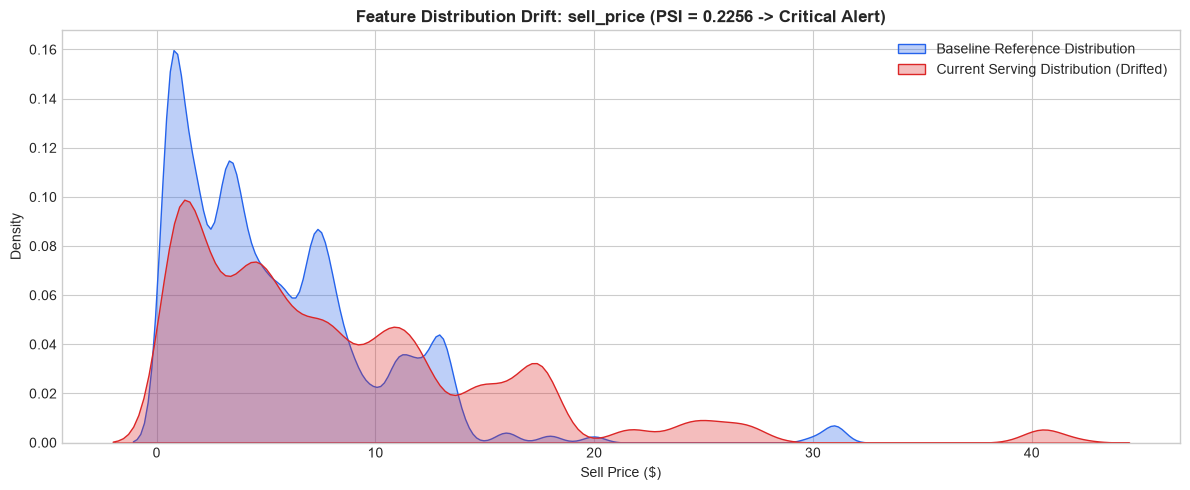

In [6]:
plt.figure(figsize=(12, 5))
sns.kdeplot(
    base_df["sell_price"].dropna(),
    label="Baseline Reference Distribution",
    fill=True,
    color="#2563eb",
    alpha=0.3,
)
sns.kdeplot(
    curr_df["sell_price"].dropna(),
    label="Current Serving Distribution (Drifted)",
    fill=True,
    color="#dc2626",
    alpha=0.3,
)

price_psi = calculate_psi(base_df["sell_price"], curr_df["sell_price"])
plt.title(
    f"Feature Distribution Drift: sell_price (PSI = {price_psi:.4f} -> Critical Alert)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Sell Price ($)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Summary & Project Completion

### End-to-End Platform Capabilities Built:
1. **Exploration (Phase 1)**: Memory reduction downcasting and synthetic generator.
2. **Baselines & Metrics (Phase 2)**: Rolling temporal cross-validation, official WRMSSE and WAPE evaluators.
3. **Statistical Suite (Phase 3)**: Croston SBA, AutoTheta, AutoETS, AutoARIMA.
4. **Feature Engineering & GBDT (Phase 4)**: Shifted lags, price momentum, discount depth, LightGBM / CatBoost with Tweedie loss.
5. **Hierarchical & Conformal (Phase 5)**: MinT reconciliation and Split Conformal Prediction intervals.
6. **MLOps & Serving (Phase 6)**: MLflow tracking, Model Registry promotion, PSI drift detector, FastAPI microservice, and interactive Streamlit UI.